# Calculo de Medidas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../../data/processed/data_imputed.csv")

df.head()

,ID_VICTIMA,ORIGEN_REPORTE,FECHA_NACIMIENTO,SEXO,FECHA_DESAPARICION,FECHA_REGISTRO,ESTATUS_VICTIMA,CVE_ENT,ENTIDAD,CVE_MUN,MUNICIPIO,SEXO_MAP,ESTATUS_MAP,FECHA_NACIMIENTO_CONFIDENCIAL,FECHA_DESAPARICION_CONFIDENCIAL,FECHA_REGISTRO_CONFIDENCIAL
0,D49C001E-41E4-45B7-B8FD-D867578F093E,FISCALIA GENERAL DE DURANGO,1986-10-15 15:29:53.512292,CONFIDENCIAL,2017-11-05 18:57:11.744796,2018-03-26 15:08:27.689360,CONFIDENCIAL,10,DURANGO,999,CONFIDENCIAL,4,3,1,1,1
1,2D2B5CD4-7AF7-48C3-887E-72F4C6403863,COMISION LOCAL DE BUSQUEDA DE PERSONAS DEL EST...,1971-06-13 00:00:00.000000,HOMBRE,2025-09-28 04:40:00.000000,2025-09-29 10:00:00.000000,DESAPARECIDA,25,SINALOA,4,CONCORDIA,1,1,0,0,0
2,6AE9098C-0C30-4709-9A2C-37F6312CD43E,PROCURADURIA GENERAL DE JUSTICIA DE LA CIUDAD ...,1986-10-15 15:29:53.512292,CONFIDENCIAL,2017-11-05 18:57:11.744796,2018-03-26 15:08:27.689360,CONFIDENCIAL,9,CIUDAD DE MÉXICO,999,CONFIDENCIAL,4,3,1,1,1
3,6B899D2D-F33D-4880-82CD-953FF972B9C3,FISCALIA GENERAL DEL ESTADO BAJA CALIFORNIA,1986-10-15 15:29:53.512292,CONFIDENCIAL,2017-11-05 18:57:11.744796,2018-03-26 15:08:27.689360,CONFIDENCIAL,2,BAJA CALIFORNIA,999,CONFIDENCIAL,4,3,1,1,1
4,3F026638-8169-4CEA-9D9A-E345B6D2D7B6,FISCALIA GENERAL DEL ESTADO BAJA CALIFORNIA,1986-10-15 15:29:53.512292,CONFIDENCIAL,2017-11-05 18:57:11.744796,2018-03-26 15:08:27.689360,CONFIDENCIAL,2,BAJA CALIFORNIA,999,CONFIDENCIAL,4,3,1,1,1


In [2]:
df_numericas = df.select_dtypes(include=['int64', 'float64'])

df_numericas.info()

<class 'pandas.DataFrame'>
RangeIndex: 133887 entries, 0 to 133886
Data columns (total 7 columns):
 #   Column                           Non-Null Count   Dtype
---  ------                           --------------   -----
 0   CVE_ENT                          133887 non-null  int64
 1   CVE_MUN                          133887 non-null  int64
 2   SEXO_MAP                         133887 non-null  int64
 3   ESTATUS_MAP                      133887 non-null  int64
 4   FECHA_NACIMIENTO_CONFIDENCIAL    133887 non-null  int64
 5   FECHA_DESAPARICION_CONFIDENCIAL  133887 non-null  int64
 6   FECHA_REGISTRO_CONFIDENCIAL      133887 non-null  int64
dtypes: int64(7)
memory usage: 7.2 MB


## Medidas de Localizacion

In [3]:
media = df_numericas.mean()
mediana = df_numericas.median()
moda = df_numericas.mode().iloc[0]

print("Media:\n", media)
print("\n")
print("Mediana:\n", mediana)
print("\n")
print("Moda:\n", moda)

Media:
 CVE_ENT                             19.427450
CVE_MUN                            430.426897
SEXO_MAP                             2.253856
ESTATUS_MAP                          1.770463
FECHA_NACIMIENTO_CONFIDENCIAL        0.367093
FECHA_DESAPARICION_CONFIDENCIAL      0.367093
FECHA_REGISTRO_CONFIDENCIAL          0.367093
dtype: float64


Mediana:
 CVE_ENT                            16.0
CVE_MUN                            77.0
SEXO_MAP                            2.0
ESTATUS_MAP                         1.0
FECHA_NACIMIENTO_CONFIDENCIAL       0.0
FECHA_DESAPARICION_CONFIDENCIAL     0.0
FECHA_REGISTRO_CONFIDENCIAL         0.0
dtype: float64


Moda:
 CVE_ENT                             14
CVE_MUN                            999
SEXO_MAP                             1
ESTATUS_MAP                          1
FECHA_NACIMIENTO_CONFIDENCIAL        0
FECHA_DESAPARICION_CONFIDENCIAL      0
FECHA_REGISTRO_CONFIDENCIAL          0
Name: 0, dtype: int64


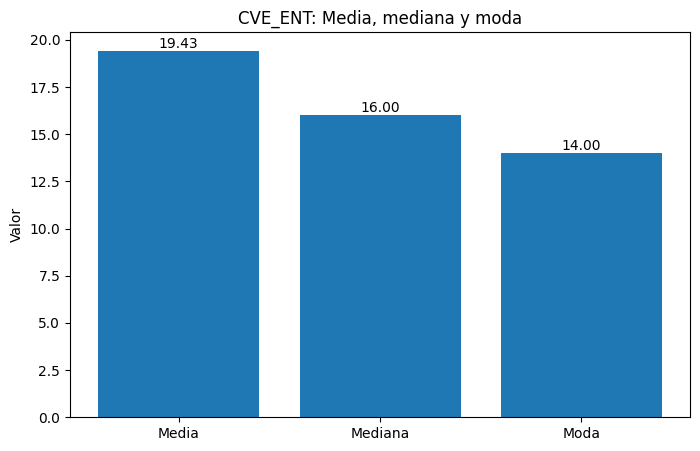

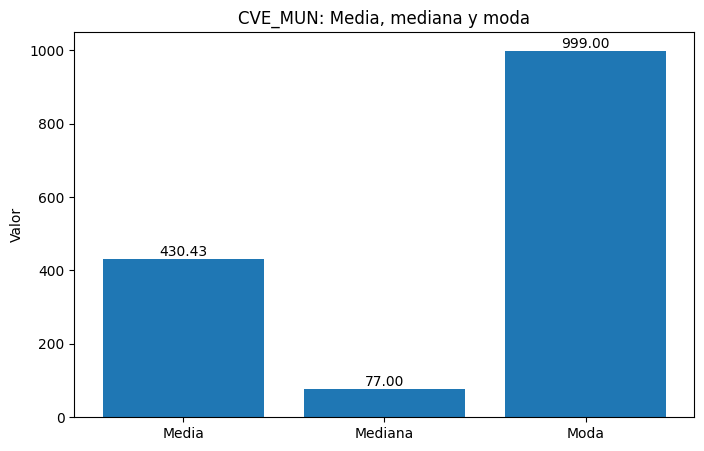

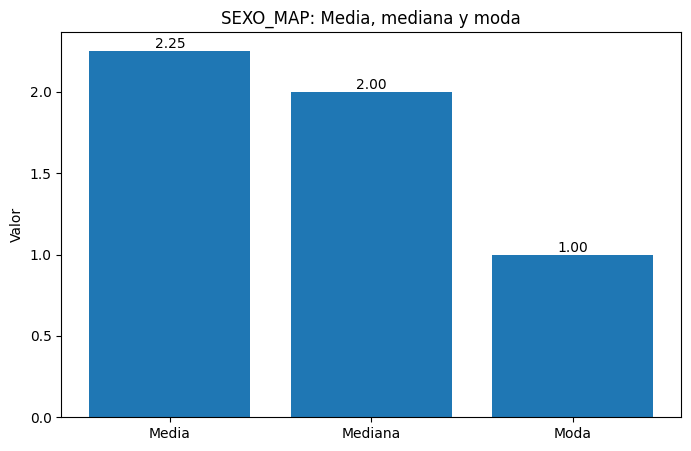

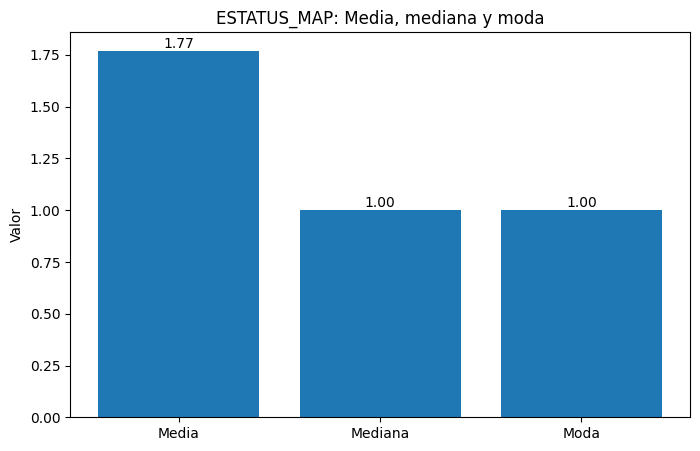

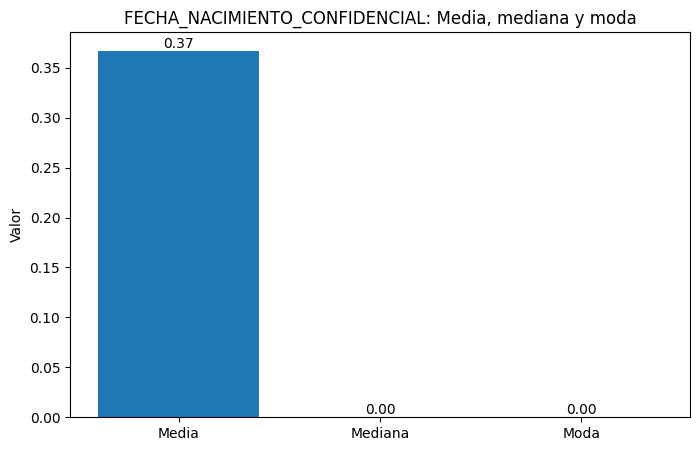

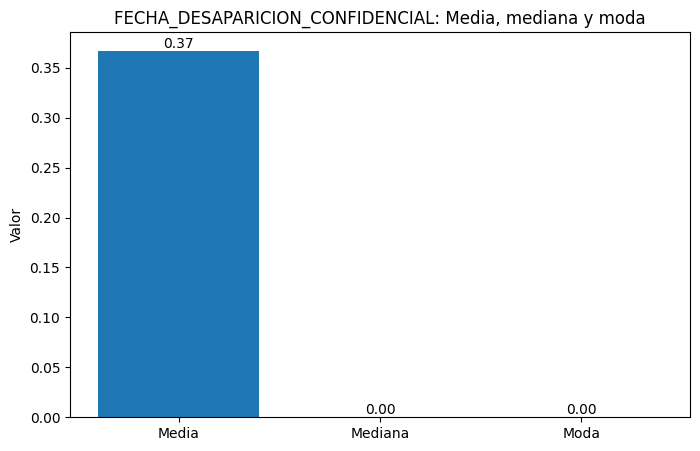

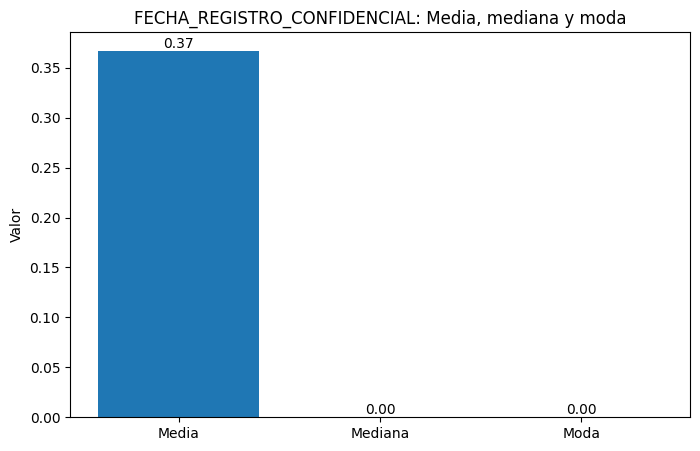

In [4]:
for col in df_numericas:
    datos = df[col]

    media = datos.mean()
    mediana = datos.median()
    moda = datos.mode().iloc[0]

    labels = ["Media", "Mediana", "Moda"]
    values = [media, mediana, moda]

    plt.figure(figsize=(8, 5))
    plt.bar(labels, values)
    plt.title(f"{col}: Media, mediana y moda")
    plt.ylabel("Valor")

    for i, value in enumerate(values):
        plt.text(i, value, f"{value:.2f}", ha="center", va="bottom")

    plt.show()

Con CVE_ENT la media (19.43), mediana (16) y moda (14) tienen una relación media > mediana > moda, lo que indica un sesgo a la derecha. Por lo que implicaría que los registros se concentran en ciertas entidades con códigos menores, pero existen entidades con valores más altos que generan una dispersión.

Con CVE_MUN la media (430.43) es mayor que la mediana (77), mientras que la moda es 999. Gracias a la moda vemos que el dataset contiene un número grande de registros clasificados como confidencial, ya que ese municipio y otros datos se encuentran clasificados en cada fila con el número 999 de CVE_MUN, lo cual indica un problema fuerte en el registro y la transparecencia de este municipio.


## Medias de Variabilidad

In [5]:
rango = df_numericas.max() - df_numericas.min()
print("Rango:")
print(rango)
print("\n")
q1 = df_numericas.quantile(0.25)
q3 = df_numericas.quantile(0.75)

rango_inter = q3 - q1

print("Rango Intercuartílico:")
print(rango_inter)
print("\n")

varianza = df_numericas.var()

print("Varianza muestral:")
print(varianza)
print("\n")

desv_std = df_numericas.std()

print("Desviación estándar:")
print(desv_std)

Rango:
CVE_ENT                             98
CVE_MUN                            998
SEXO_MAP                             3
ESTATUS_MAP                          2
FECHA_NACIMIENTO_CONFIDENCIAL        1
FECHA_DESAPARICION_CONFIDENCIAL      1
FECHA_REGISTRO_CONFIDENCIAL          1
dtype: int64


Rango Intercuartílico:
CVE_ENT                             14.0
CVE_MUN                            977.0
SEXO_MAP                             3.0
ESTATUS_MAP                          2.0
FECHA_NACIMIENTO_CONFIDENCIAL        1.0
FECHA_DESAPARICION_CONFIDENCIAL      1.0
FECHA_REGISTRO_CONFIDENCIAL          1.0
dtype: float64


Varianza muestral:
CVE_ENT                               207.692776
CVE_MUN                            223326.204534
SEXO_MAP                                1.889592
ESTATUS_MAP                             0.911043
FECHA_NACIMIENTO_CONFIDENCIAL           0.232338
FECHA_DESAPARICION_CONFIDENCIAL         0.232338
FECHA_REGISTRO_CONFIDENCIAL             0.232338
dtype: float64



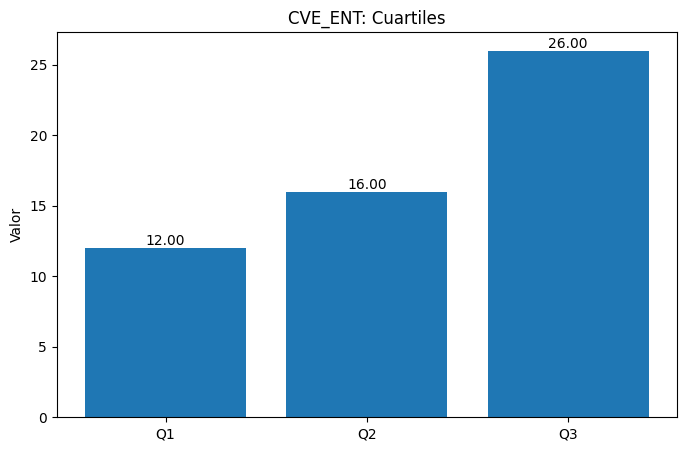

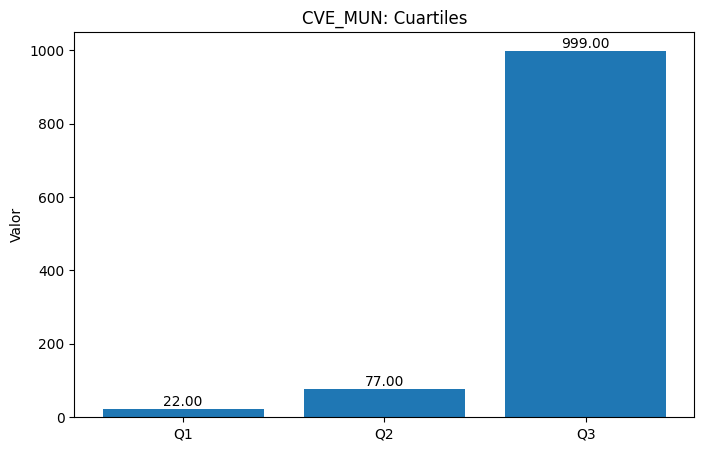

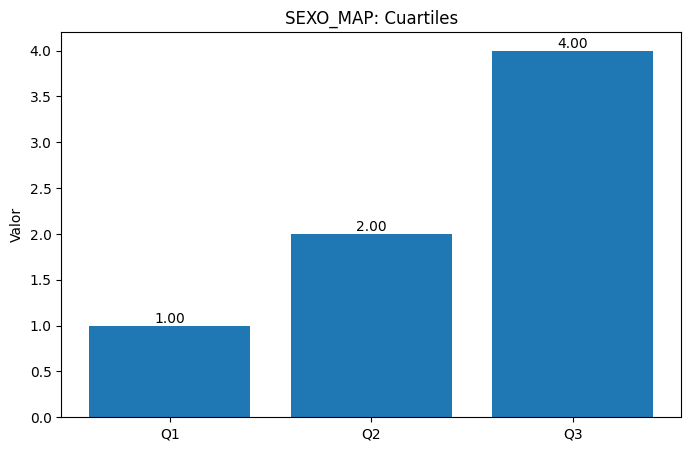

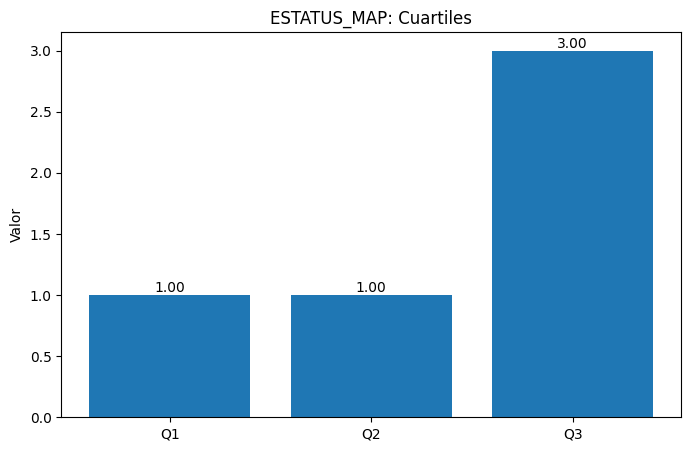

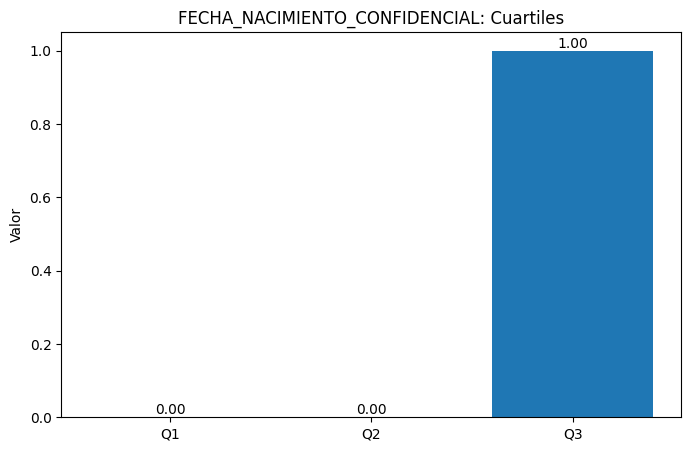

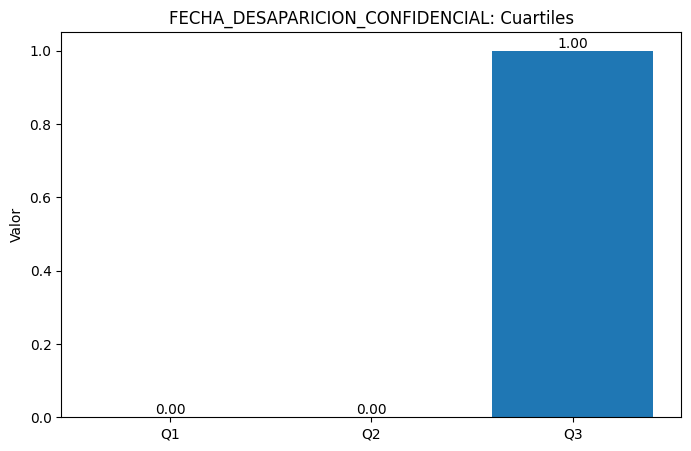

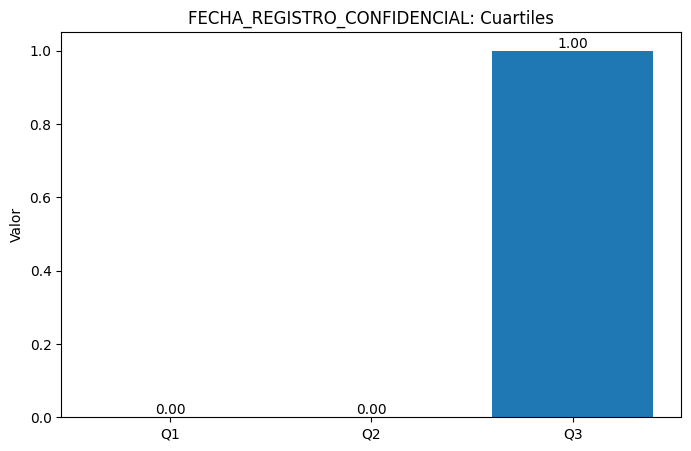

In [6]:
for col in df_numericas:
    datos = df[col]

    q1 = datos.quantile(0.25)
    q2 = datos.quantile(0.50)
    q3 = datos.quantile(0.75)

    labels = ["Q1", "Q2", "Q3"]
    values = [q1, q2, q3]

    plt.figure(figsize=(8, 5))
    plt.bar(labels, values)
    plt.title(f"{col}: Cuartiles")
    plt.ylabel("Valor")

    for i, value in enumerate(values):
        plt.text(i, value, f"{value:.2f}", ha="center", va="bottom")

    plt.show()

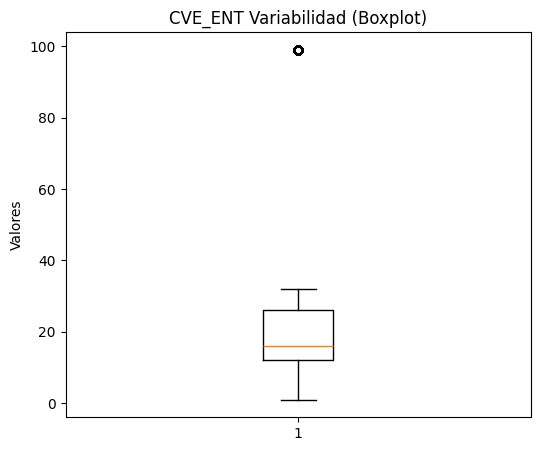

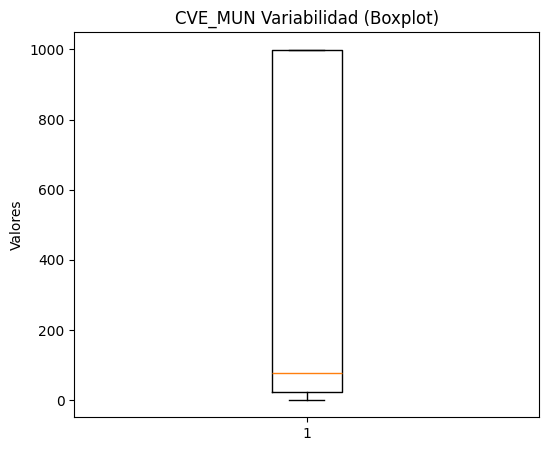

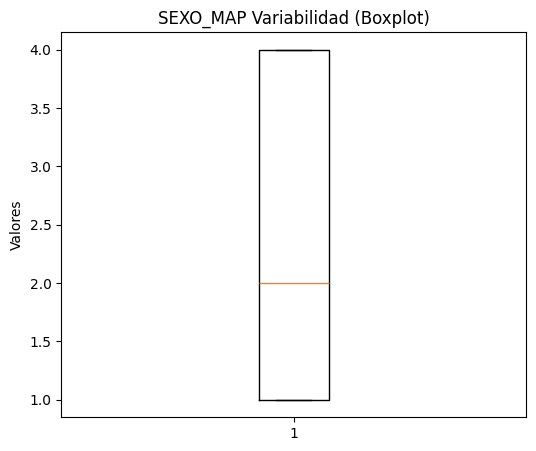

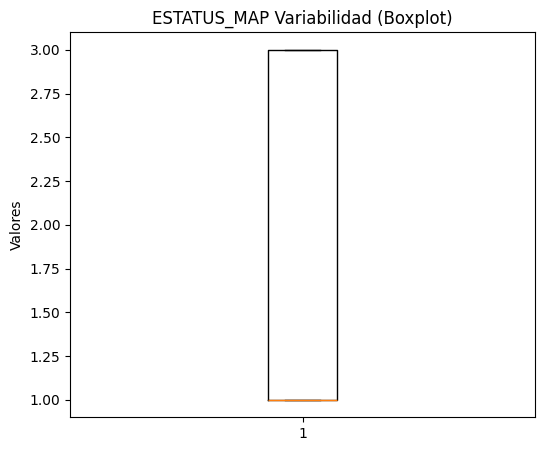

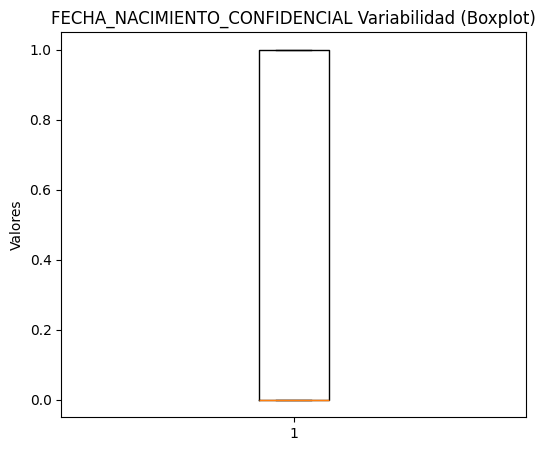

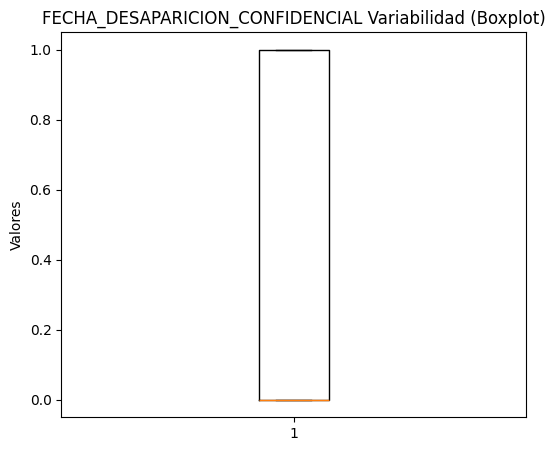

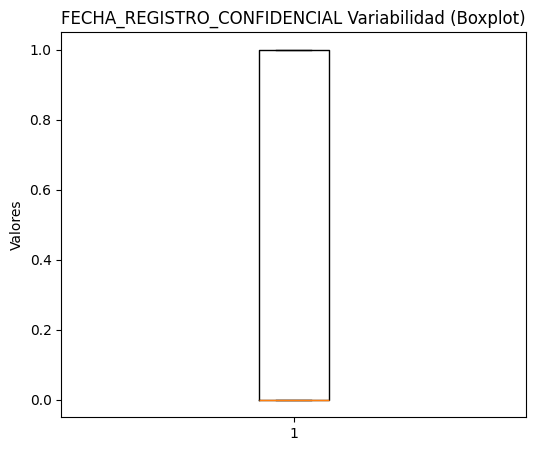

In [7]:
for col in df_numericas:
    datos = df[col]

    plt.figure(figsize=(6,5))
    plt.boxplot(datos)

    plt.title(f"{col} Variabilidad (Boxplot)")
    plt.ylabel("Valores")

    plt.show()

En CVE_ENT el rango es de 98 y la desviación estándar es de 14.41, lo que nos indica una dispersión moderada. Además, el rango intercuartílico que es de 14 muestra que el 50% central de los datos está relativamente concentrado.  

Ahora bien, en CVE_MUN el rango es de 998 y la desviación estándar es de 472.57, lo que nos da una alta dispersión.  Gracias al tercer cuartil (999) se nos confirma que una gran proporción de los datos se concentra en ese valor. De esta forma nos indica que los registros no están distribuidos homogéneamente entre municipios, sino que una parte grande está agrupada bajo categorías confidenciales lo cual es un gran problema para la transparencia con la gente.

## Medidas de Heteroginidad

In [8]:
gini_resultados = {}

for col in df_numericas.columns:
    
    proporciones = df_numericas[col].value_counts(normalize=True)
    
    gini = 1 - np.sum(proporciones**2)
    
    k = len(df_numericas[col].unique())
    gini_max = 1 - 1/k
    
    print("Columna:", col)
    print("\n")
    print(proporciones.head())
    print("Gini max:", gini_max)
    print("Índice de heterogeneidad Gini:", gini)
    
    gini_resultados[col] = gini

Columna: CVE_ENT


CVE_ENT
14    0.110623
15    0.107135
28    0.100473
16    0.053119
19    0.052992
Name: proportion, dtype: float64
Gini max: 0.9696969696969697
Índice de heterogeneidad Gini: 0.9420154904498209
Columna: CVE_MUN


CVE_MUN
999    0.407411
4      0.028912
6      0.020756
15     0.019531
39     0.019412
Name: proportion, dtype: float64
Gini max: 0.9963636363636363
Índice de heterogeneidad Gini: 0.8278210098583245
Columna: SEXO_MAP


SEXO_MAP
1    0.482989
4    0.367093
2    0.147259
3    0.002659
Name: proportion, dtype: float64
Gini max: 0.75
Índice de heterogeneidad Gini: 0.6102717362832368
Columna: ESTATUS_MAP


ESTATUS_MAP
1    0.596630
3    0.367093
2    0.036277
Name: proportion, dtype: float64
Gini max: 0.6666666666666667
Índice de heterogeneidad Gini: 0.5079592620940877
Columna: FECHA_NACIMIENTO_CONFIDENCIAL


FECHA_NACIMIENTO_CONFIDENCIAL
0    0.632907
1    0.367093
Name: proportion, dtype: float64
Gini max: 0.5
Índice de heterogeneidad Gini: 0.4646715361667648

In [9]:
entropia_resultados = {}

for col in df_numericas.columns:
    
    proporciones = df_numericas[col].value_counts(normalize=True)
    
    entropia = -np.sum(proporciones * np.log2(proporciones))
    
    print("Columna:", col)
    print("Entropía:", entropia)
    print("\n")

    entropia_resultados[col] = entropia

Columna: CVE_ENT
Entropía: 4.460460563196675


Columna: CVE_MUN
Entropía: 4.740778462872435


Columna: SEXO_MAP
Entropía: 1.4675522996353296


Columna: ESTATUS_MAP
Entropía: 1.148858382191411


Columna: FECHA_NACIMIENTO_CONFIDENCIAL
Entropía: 0.9484139556788277


Columna: FECHA_DESAPARICION_CONFIDENCIAL
Entropía: 0.9484139556788277


Columna: FECHA_REGISTRO_CONFIDENCIAL
Entropía: 0.9484139556788277




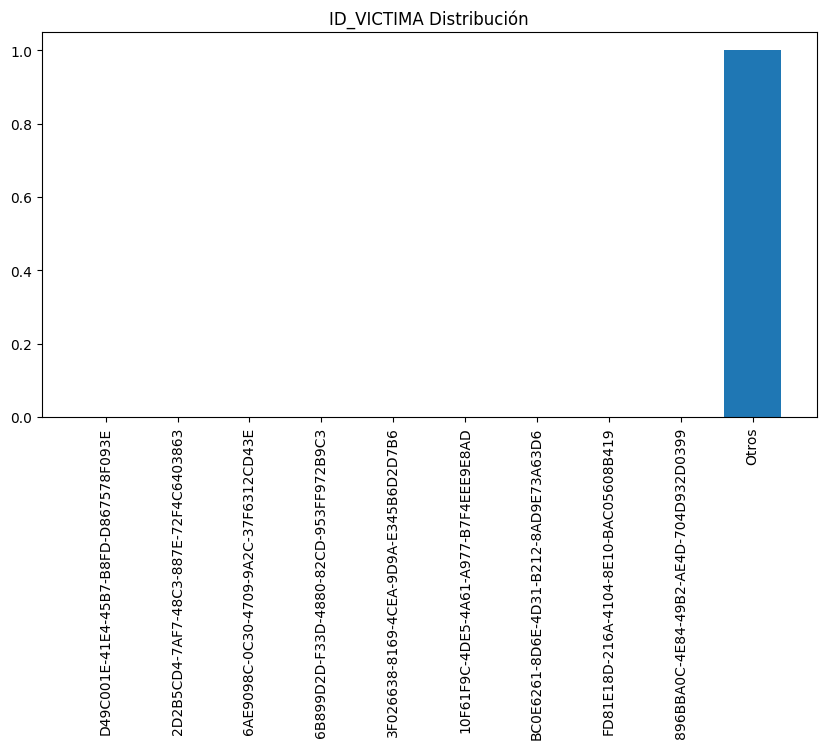

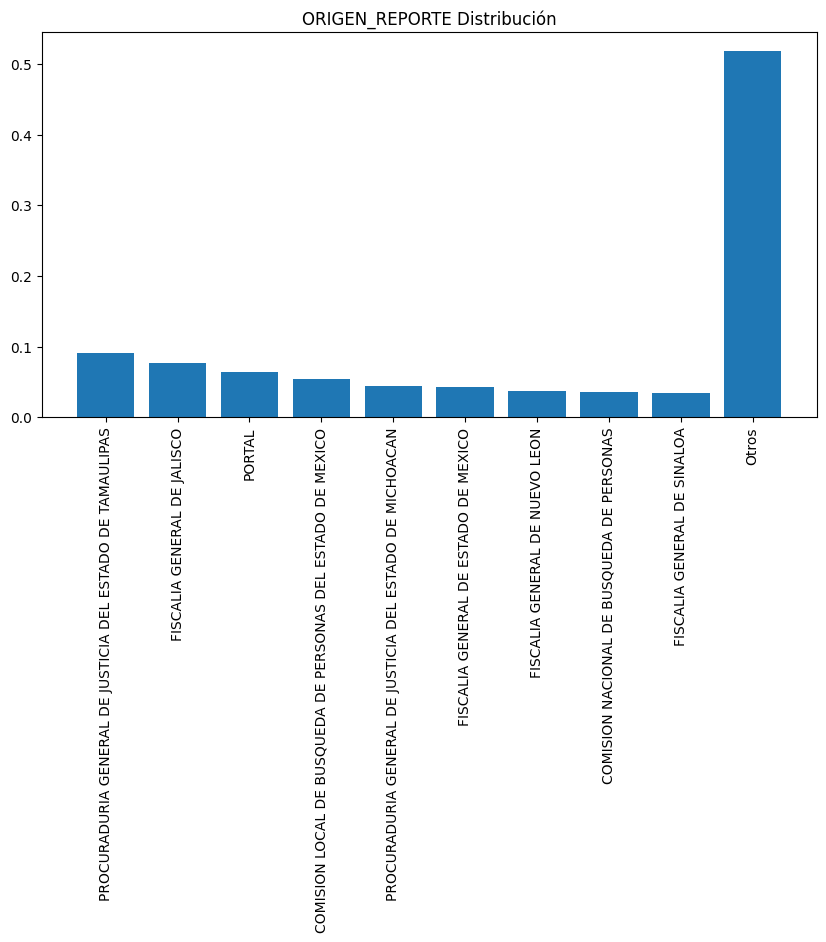

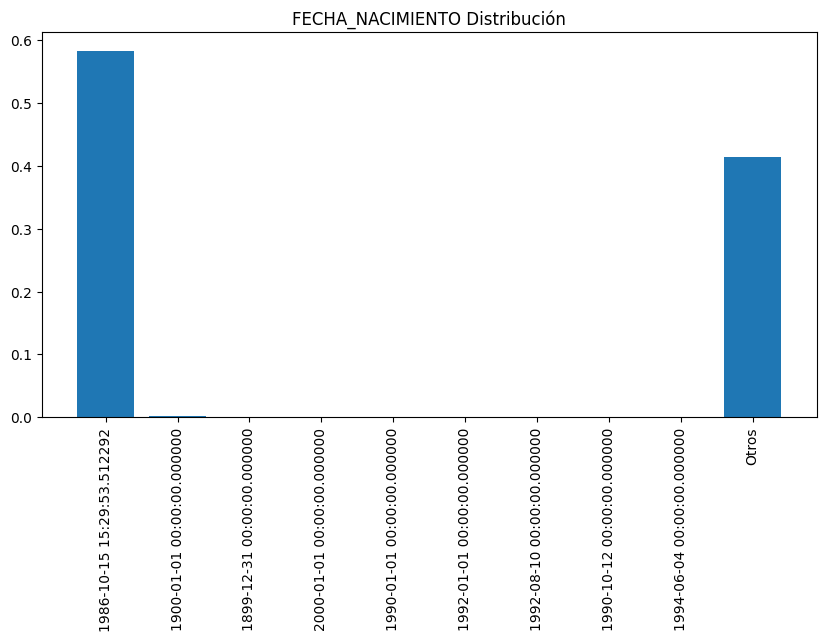

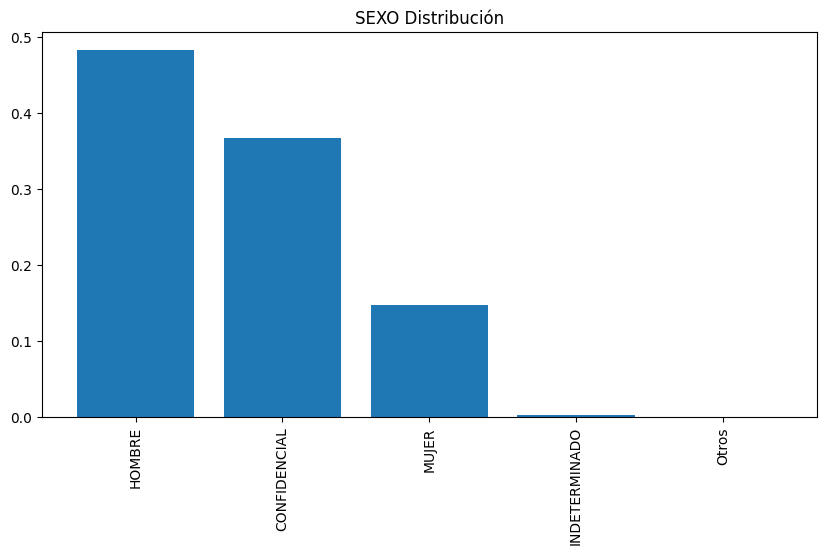

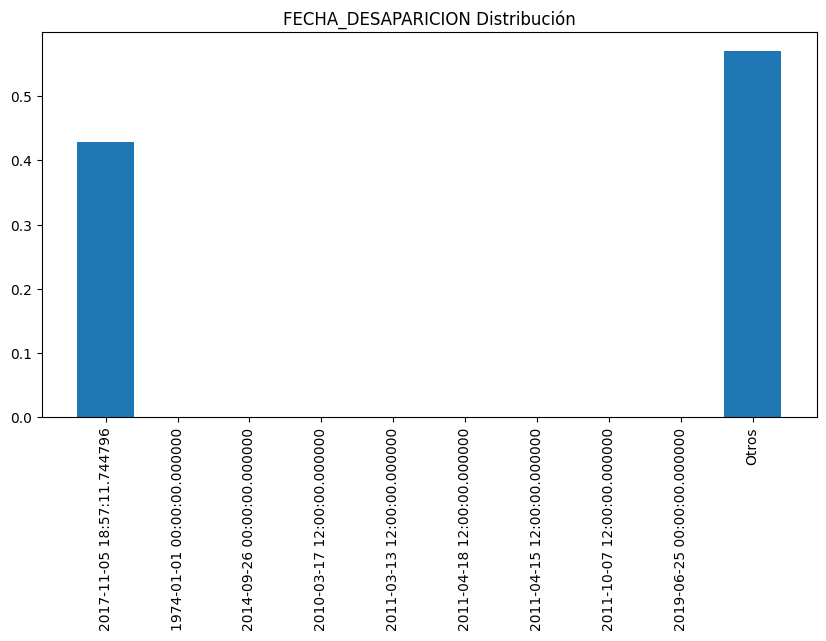

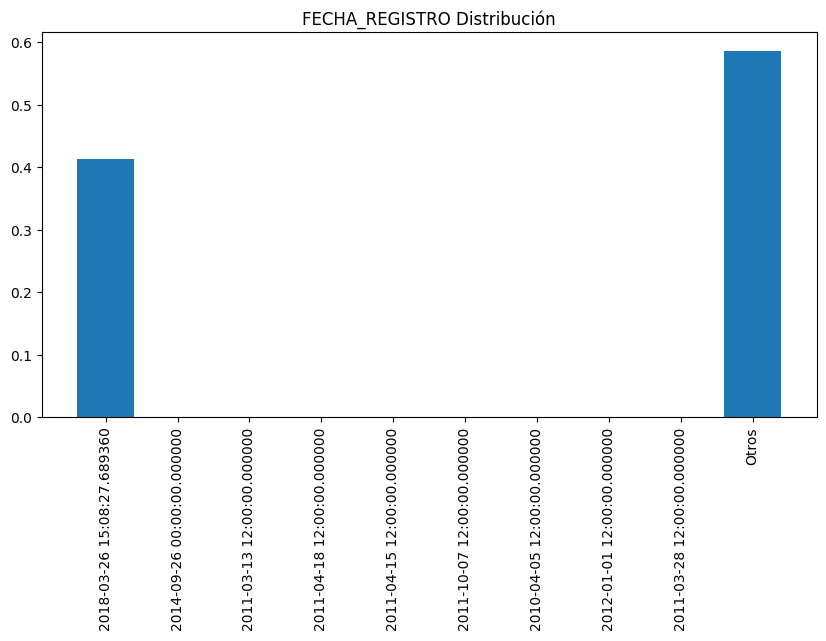

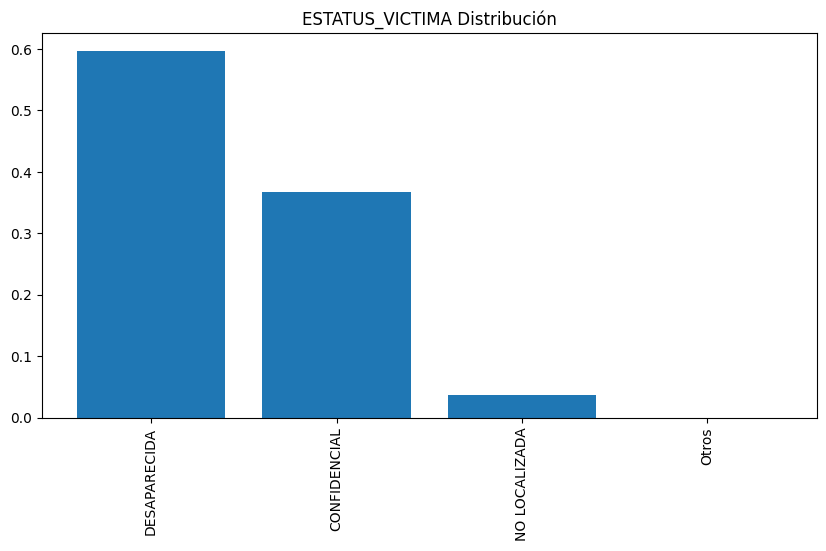

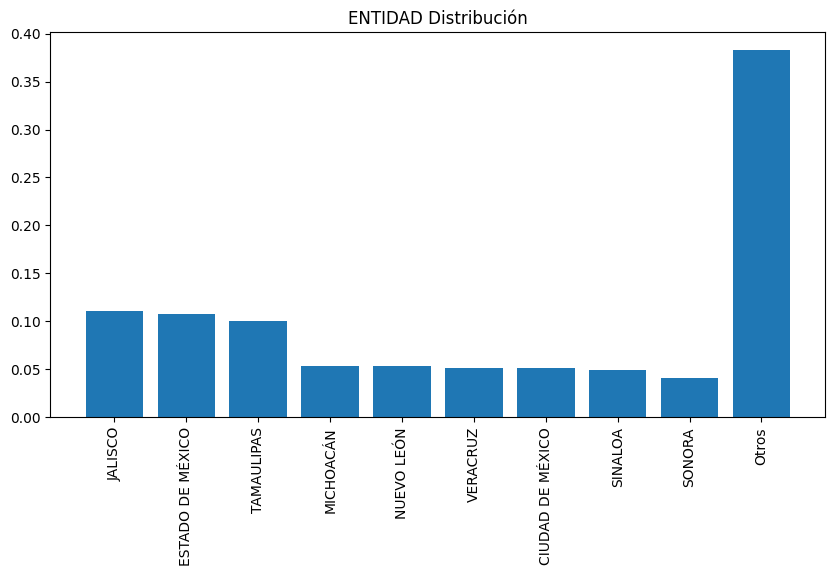

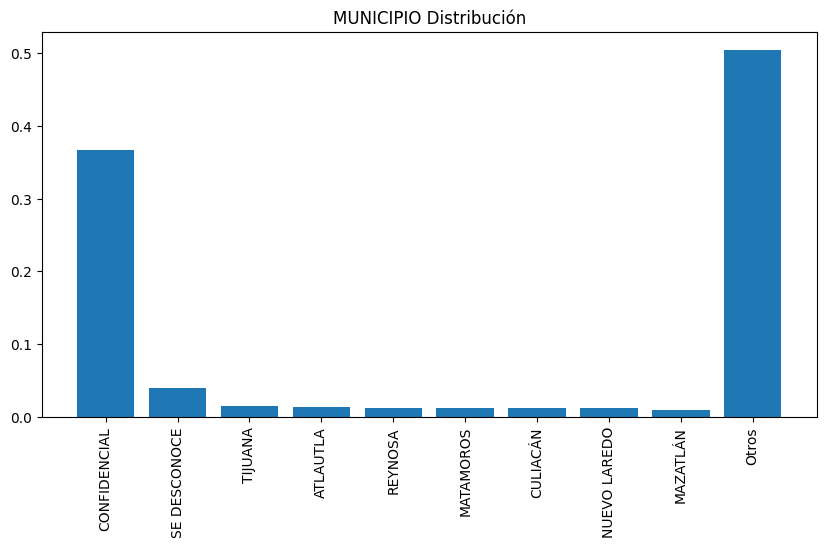

In [20]:
categoricas = df.select_dtypes(include=['object', 'string']).columns

for col in categoricas:
    value_c = df[col].value_counts(normalize=True)

    populares = value_c.head(9)
    otros = pd.Series({'Otros': value_c[9:].sum()})

    proporciones = pd.concat([populares, otros])

    plt.figure(figsize=(10,5))
    plt.bar(proporciones.index.astype(str), proporciones.values)

    plt.title(f"{col} Distribución")
    plt.xticks(rotation=90)

    plt.show()

Hay datos que son importantes notar, como una disribución curiosa de los datos visibles en la parte de sexo, mientras se consideraría que hay una mayor cantidad de reportes de personas desaparecidas de sexo femenino, es lo contrario, hay una distribución mayor en la de los hombres, aunque no es que podamos sacar una conclusión con esto ya que hay bastantes datos confidenciales.
Lamentablemente también podemos notar que existe una fuerte distribución en el estatus de la víctima como desaparecida, esto nos da una fuerte conclusión de lo mal que se tratan estos reportes en México para la localización de personas.
Además vemos la distribución de las entidades, algunas de las que mayor distribución tienen son Jalisco, Edo de México y Tamaulipas, lo cual nos da a qué aiutoridades son las que debemos de exigir más.

## Medidas de Concentracion

In [29]:
for col in df_numericas:
    
    x = np.sort(df[col].values)
    
    N = len(x)
    media = np.mean(x)
    
    F = np.arange(1, N+1) / N
    
    Q = np.cumsum(x) / (N * media)
    
    R = np.sum(F[:-1] - Q[:-1]) / np.sum(F[:-1])
    
    print("Columna:", col)
    print("Índice de concentración R:", R)
    print("\n")


Columna: CVE_ENT
Índice de concentración R: 0.31848964374194716


Columna: CVE_MUN
Índice de concentración R: 0.5547724718378493


Columna: SEXO_MAP
Índice de concentración R: 0.3172728324602717


Columna: ESTATUS_MAP
Índice de concentración R: 0.26716282952639325


Columna: FECHA_NACIMIENTO_CONFIDENCIAL
Índice de concentración R: 0.6329115814947045


Columna: FECHA_DESAPARICION_CONFIDENCIAL
Índice de concentración R: 0.6329115814947045


Columna: FECHA_REGISTRO_CONFIDENCIAL
Índice de concentración R: 0.6329115814947045




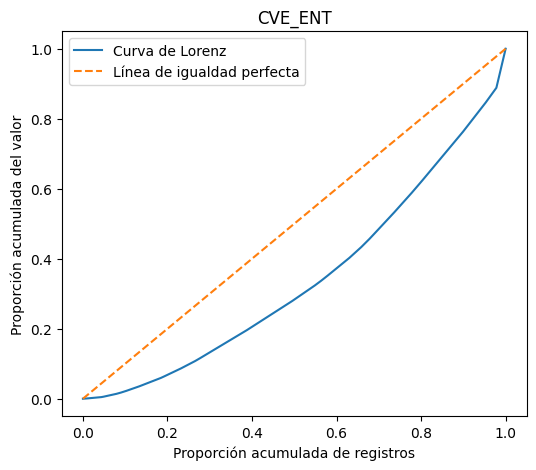

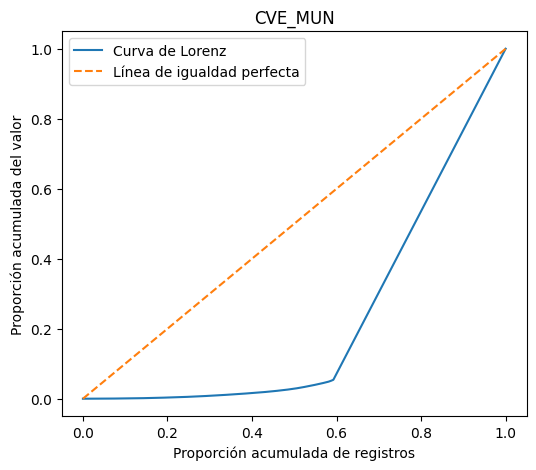

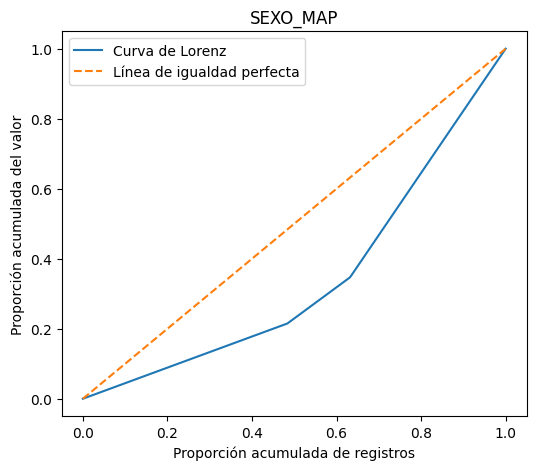

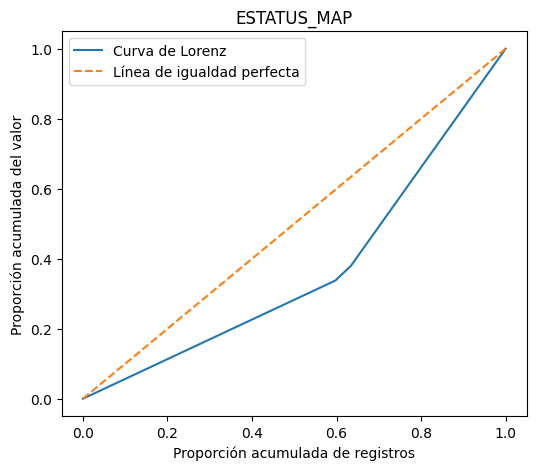

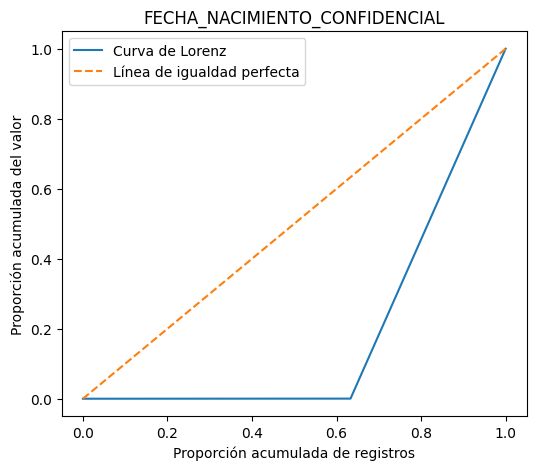

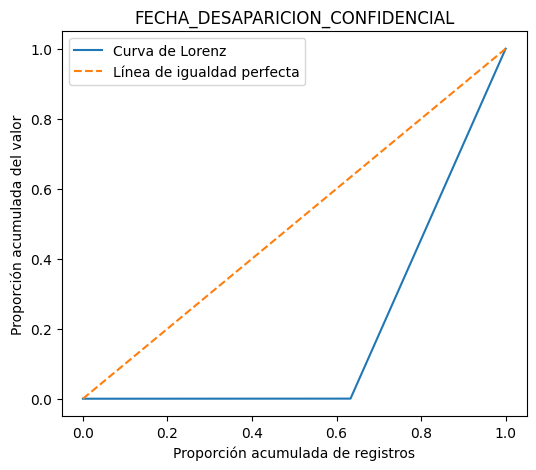

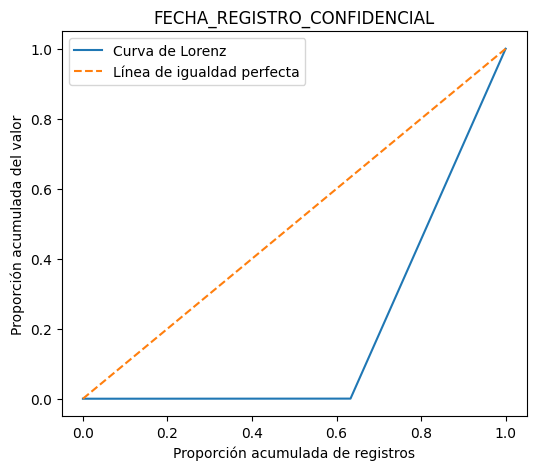

In [23]:
for col in df_numericas:
    x = np.sort(df[col].values)
    
    N = len(x)
    media = np.mean(x)
    
    F = np.arange(1, N+1) / N
    
    Q = np.cumsum(x) / (N * media)
    
    plt.figure(figsize=(6,5))
    plt.plot(F, Q, label="Curva de Lorenz")
    plt.plot([0,1], [0,1], linestyle="--", label="Línea de igualdad perfecta")

    plt.title(col)
    plt.xlabel("Proporción acumulada de registros")
    plt.ylabel("Proporción acumulada del valor")
    
    plt.legend()
    plt.show()

Las curvas de Lorenz nos muestran que la distribución se aleja significativamente de la igualdad perfecta, sobre todo confirmando desigualdades en la parte de los municipios y en cómo se distribuyen los reportes. Además de casos como la fecha de registro.

## Conclusiones

Gracias al análisis podemos evidenciar una gran problemática **Problema de transparencia**, la concentración de datos de forma confidencial nos señala un problema importante en el registro y la disponibilidad de información para todas las personas, limitando el análisis geográfico detallado y una mayor responsabilidad a autoridades.